In [58]:
#imports
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import sys
import os
from astropy.cosmology import Planck18 as cosmo
import ast




In [78]:
# --- User toggle ---
Cristina = False
Shar = not Cristina 

# --- System Configurations ---

if Cristina:
    print("[CONFIG] Using Cristina's local MacBook setup")
    sys.path.insert(0, "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/Users/andradenebula/rubin_sim_data"
    db_dir = "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub"
    base_dir = '/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output'

elif Shar:
    print("[CONFIG] Using Shar's Dirac server setup")
    sys.path.insert(0, "/lustre/lrspec/metrics")
    sys.path.insert(0, "/home/3155/metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/lustre/lrspec/metrics/rubin_sim_data"
    db_dir = "/lustre/lrspec/metrics"
    base_dir = '/lustre/lrspec/metrics/results'

# Shared config
sys.path.append(os.path.abspath(".."))  # For shared_utils


[CONFIG] Using Shar's Dirac server setup


In [45]:

import os
print(os.getcwd())


/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/LFBOT


In [80]:
#this happens twice because idk why but it only works like that
#...you still have to run it twice if it gives warnings
# C: Make sure you save your metric file before running. 

metric_filename = "local_LFBOTmetric"
s_u = "shared_utils"

# --- Reload metric module ---
if metric_filename in sys.modules:
    del sys.modules[metric_filename]
metric = __import__(metric_filename)
importlib.reload(metric)

# --- Reload shared_utils module ---
if s_u in sys.modules:
    del sys.modules[s_u]
shared_utils = __import__(s_u)
importlib.reload(shared_utils)

print(f"[INFO] Loaded metric module: {metric_filename}")
print(f"[INFO] Loaded shared_utils module")



[INFO] Loaded metric module: local_LFBOTmetric
[INFO] Loaded shared_utils module


In [267]:
#metric configurations
#metric configurations
testname=None  
#use this to add text to the filename
#if you're testing template or population variables other than the below variables

testname_metric_only=None 
#use this to add text to the filename for the observation record df only (does not change pop/template filenames)
#so for anything you're changing that's only about the detection criteria

use_log_time = False

#control whether we generate new files
generate_new_templates = False
generate_new_pop = False
make_debug_plots = False #toggle whether or not the pop generation makes plots

#population variables
rate_density = 420e-9
# rate_density=1e-5

# apply None for non-use case 
z_min, z_max = 0.00226, 0.3
d_min, d_max = None, None

#other
gal_lat_cut = None #latitude cut, for Galactic phenomena
use_extinction = True
t_start = 1 #start time in days
t_end = 3652

# Whether to remove Metric_temp_* folders after running
clean_temp = True  

#cadence variables
cadences = ['four_roll_v4.3.1_10yrs', 'baseline_v4.3.1_10yrs','noroll_v3.6_10yrs', 'baseline_v3.6_10yrs']
ignore_triples = False #turn this to true to ignore triples
filters = ['u', 'g', 'r', 'i', 'z', 'y'] #doesn't work rn i think but
#if we wanted to look at less filters then we would adjust that here

# Standardized output paths for this science case
# paths = metric.get_output_paths(case_label="GRBafterglows")  # <- can change to 'KNe' etc.
paths = shared_utils.build_filenames(testname=testname,
                        testname_metric_only=testname_metric_only,
                        science_case="LFBOTs", 
                        rate_density=rate_density, 
                        z_min=z_min, 
                        z_max=z_max,
                        d_min=d_min, 
                        d_max=d_max,
                        ignore_triples=ignore_triples,                   
                        use_extinction=use_extinction,
                        base_dir=base_dir)


templates_file, pop_file, df_file, storage_dir, summary_filename = paths


LFBOTs_den_4.2e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_None


In [57]:
paths

('/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/LFBOTs/LFBOTs_den_1e-08_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_None_templates.pkl',
 '/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/LFBOTs/LFBOTs_den_1e-08_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_None_population.pkl',
 '/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/LFBOTs/LFBOTs_den_1e-08_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_None_None_obs_record',
 '/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/LFBOTs',
 '/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/LFBOTs/LFBOTs_den_1e-08_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_None_None_multi_summary.csv')

In [268]:
#load and/or generate light curves
shared_lc_model = shared_utils.load_or_generate_templates(metric.LC,
    templates_file=templates_file,
    generate_new=generate_new_templates
)

[INFO] Loading light curve templates from /lustre/lrspec/metrics/results/LFBOTs/LFBOTs_den_4.2e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_None_templates.pkl.
Loaded LFBOT templates from /lustre/lrspec/metrics/results/LFBOTs/LFBOTs_den_4.2e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_None_templates.pkl


In [136]:
importlib.reload(shared_utils)

<module 'shared_utils' from '/home/3155/metrics/Multi_Transient_Metrics_Hub/shared_utils.py'>

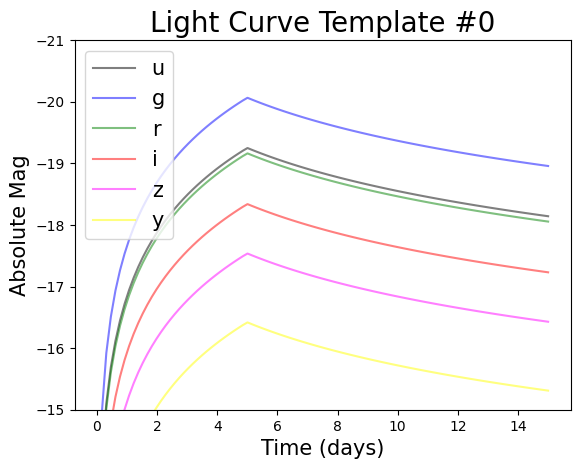

In [269]:
#plot light curves from pkl file if desired
ylim=(-15, -21)
shared_utils.plot_some_lcs_from_pkl(templates_file, num=1, use_log_time = False,plot_overlap=True,ylim=ylim)

In [270]:
# Load or generate population slicer
slicer = shared_utils.load_or_generate_population(use_extinction=use_extinction,
    t_start=t_start,
    t_end=t_end,
    d_min=d_min,
    d_max=d_max,
    z_min=z_min,
    z_max=z_max,
    seed=42,
    num_lightcurves=1000,
    gal_lat_cut=gal_lat_cut,
    rate_density=rate_density,
    pop_file=pop_file,
    generate_new=generate_new_pop,
    make_debug_plots=make_debug_plots
)

[INFO] Loading population from /lustre/lrspec/metrics/results/LFBOTs/LFBOTs_den_4.2e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_None_population.pkl
Loaded population from /lustre/lrspec/metrics/results/LFBOTs/LFBOTs_den_4.2e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_None_population.pkl


## All 10 years

In [68]:
bbfluratios=[0.47184822835586304,
 1.0,
 0.4356131668415372,
 0.20399584045639102,
 0.09743514963840874,
 0.0347938320584038]

filters = ['u','g','r','i','z','y']
# Assuming bbfluratios has already been computed from your code
mag_offsets = -2.5 * np.log10(bbfluratios)

# Optionally normalize to g = 22 mag
g_mag = 22
magnitudes = {f: g_mag + dm for f, dm in zip(filters, mag_offsets)}
magnitudes


{'u': np.float64(22.81549417813454),
 'g': np.float64(22.0),
 'r': np.float64(22.902247504337247),
 'i': np.float64(23.72594671973493),
 'z': np.float64(24.528210858825013),
 'y': np.float64(25.64624434274951)}

In [234]:
importlib.reload(metric)

<module 'local_LFBOTmetric' from '/home/3155/metrics/Multi_Transient_Metrics_Hub/LFBOT/local_LFBOTmetric.py'>


--- Running four_roll_v4.3.1_10yrs ---
EBV included

Inspecting one obs_record before saving to CSV:
mjd_obs         | type: <class 'list'> | length: 754
mag_obs         | type: <class 'list'> | length: 754
snr_obs         | type: <class 'list'> | length: 754
filter          | type: <class 'list'> | length: 754
first_det_mjd   | type: <class 'numpy.float64'> | value: 62849.17243982359
last_det_mjd    | type: <class 'numpy.float64'> | value: 62859.17868039632
fade_time_days  | type: <class 'numpy.float64'> | value: 13.123174886430206
sid_duplicate   | type: <class 'numpy.int64'> | value: 1
file_indx       | type: <class 'numpy.int64'> | value: 22
ra              | type: <class 'numpy.float64'> | value: 0.6135923151542564
dec             | type: <class 'numpy.float64'> | value: -0.5848608108840141
distance_Mpc    | type: <class 'numpy.float64'> | value: 412.7801962677546
peak_mjd_observed | type: <class 'numpy.float64'> | value: 62857.12679422711
peak_mag_observed | type: <class 'numpy.

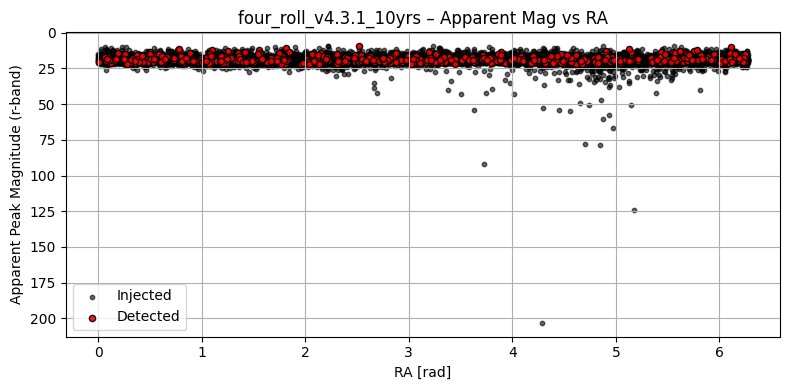

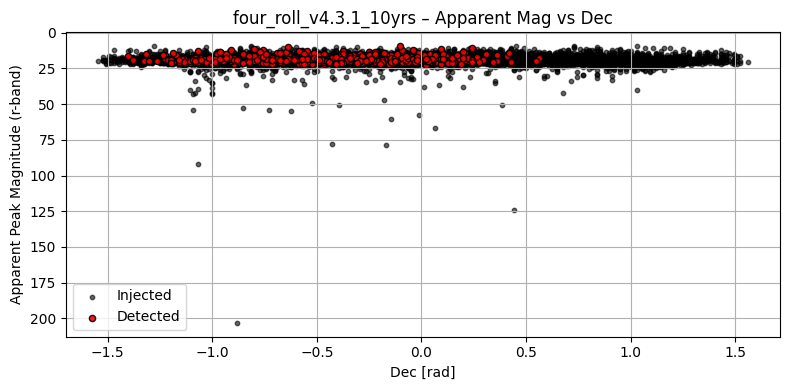

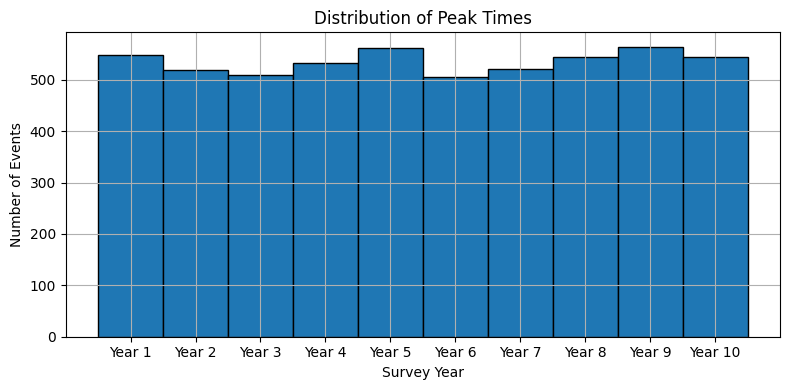

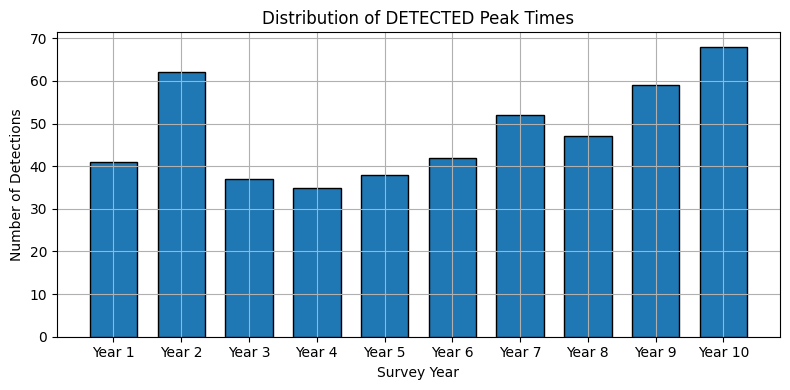

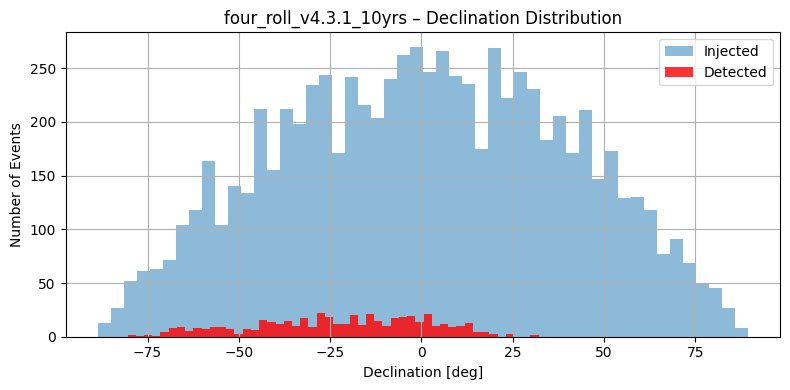

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_four_roll_v4.3.1_10yrs

--- Running baseline_v4.3.1_10yrs ---


KeyboardInterrupt: 

In [149]:
#run detection metric
df_obs = shared_utils.run_detect(metric, slicer, cadences, shared_lc_model, db_dir, storage_dir, df_file, is_grb=True, ignore_triples=ignore_triples, debug=True, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)

In [ ]:
df_obs

In [259]:
importlib.reload(metric)

<module 'local_LFBOTmetric' from '/home/3155/metrics/Multi_Transient_Metrics_Hub/LFBOT/local_LFBOTmetric.py'>

In [275]:
#choose what to run in run_multi_metrics #'detect',  'GRBcharacterize', 'GRB_spec_trigger', 'GRBDetect'
# we can remove historical if we want
multi_metrics = metric.get_multi_metrics(shared_lc_model, include=['detect'], use_extinction=use_extinction)



--- Running four_roll_v4.3.1_10yrs ---
EBV included
[DEBUG] Detected RA, Dec: 68.91, -1.79
[DEBUG] Detected RA, Dec: 354.38, -15.09


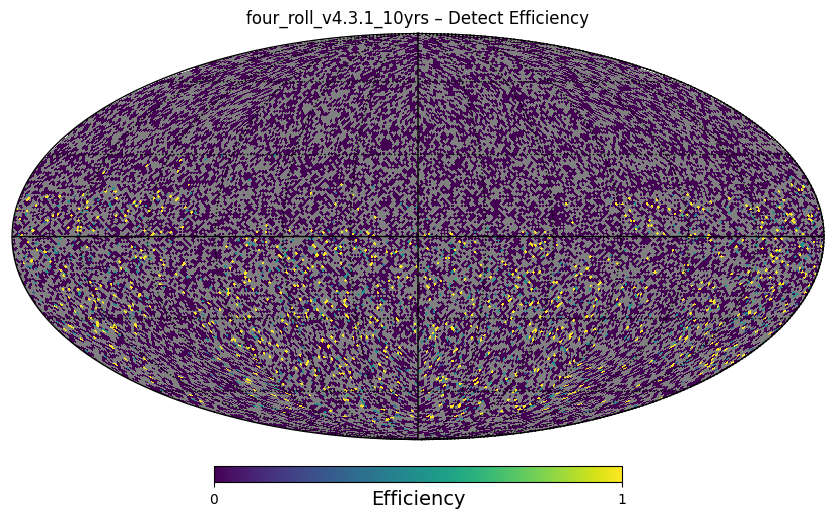

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_four_roll_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_baseline_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_noroll_v3.6_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_baseline_v3.6_10yrs

--- Running baseline_v4.3.1_10yrs ---
[DEBUG] Detected RA, Dec: 310.78, -12.64
[DEBUG] Detected RA, Dec: 95.62, -21.38


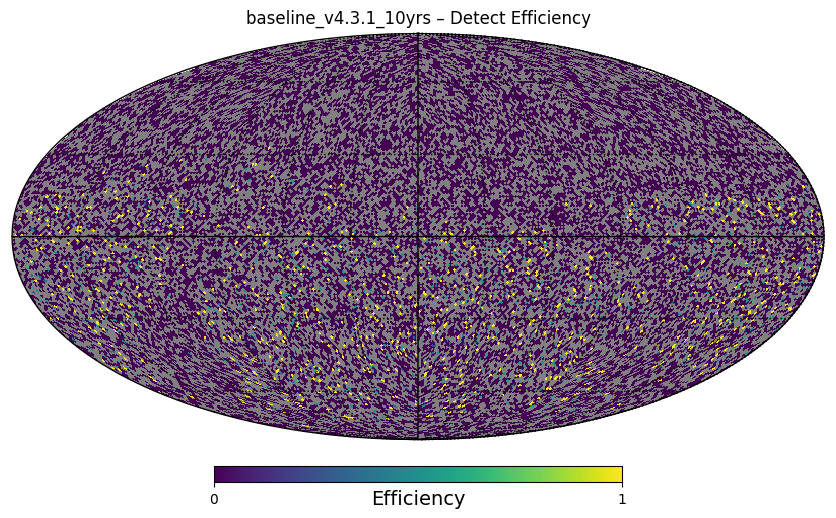

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_four_roll_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_baseline_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_noroll_v3.6_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_baseline_v3.6_10yrs

--- Running noroll_v3.6_10yrs ---
[DEBUG] Detected RA, Dec: 118.12, -13.86
[DEBUG] Detected RA, Dec: 185.62, -6.58
[DEBUG] Detected RA, Dec: 175.08, -7.18


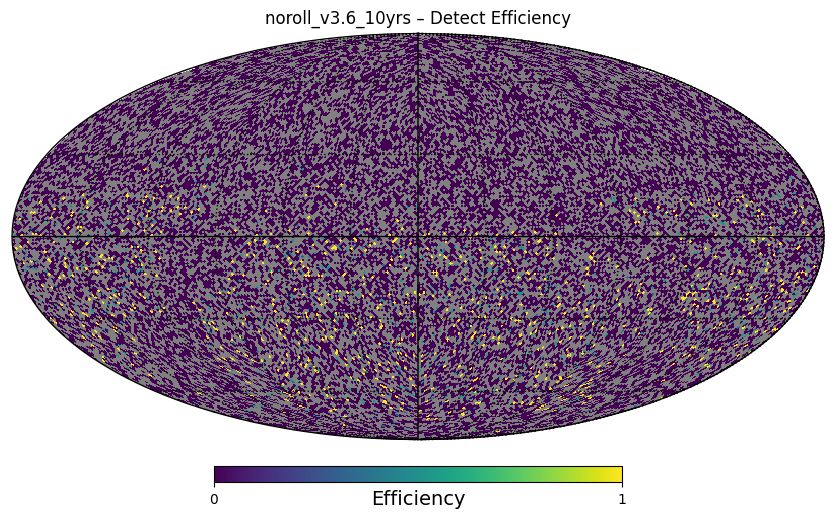

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_four_roll_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_baseline_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_noroll_v3.6_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_baseline_v3.6_10yrs

--- Running baseline_v3.6_10yrs ---
[DEBUG] Detected RA, Dec: 36.56, -30.69
[DEBUG] Detected RA, Dec: 180.00, 10.20
[DEBUG] Detected RA, Dec: 222.89, -31.39


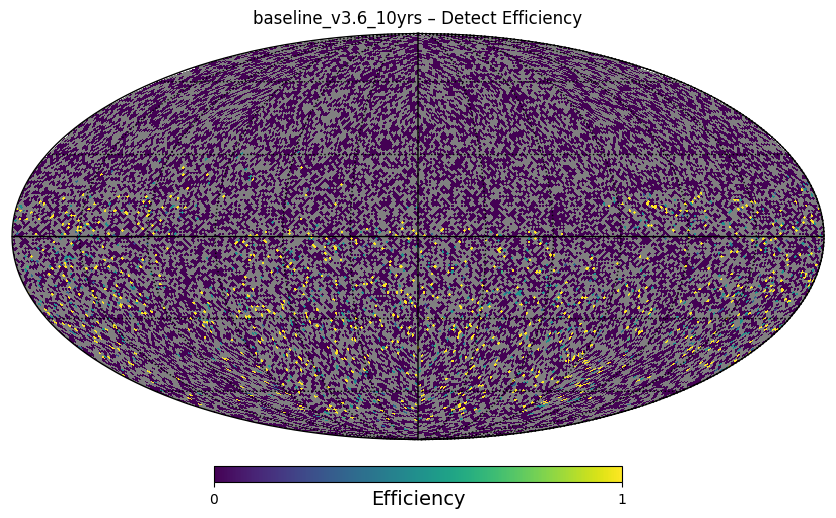

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_four_roll_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_baseline_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_noroll_v3.6_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/LFBOTs/Metric_temp_baseline_v3.6_10yrs
saved summary to  /lustre/lrspec/metrics/results/LFBOTs/LFBOTs_den_4.2e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_None_None_multi_summary.csv


In [276]:
sum_df_2 = shared_utils.run_multi_metrics(multi_metrics, slicer, cadences, shared_lc_model, db_dir=db_dir, storage_dir=storage_dir,summary_filename=summary_filename, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)

In [277]:
sum_df_2

,Sum,run,n_events_full_sky
four_roll_v4.3.1_10yrs_Detect_Metric,1592.0,four_roll_v4.3.1_10yrs,33267
baseline_v4.3.1_10yrs_Detect_Metric,1533.0,baseline_v4.3.1_10yrs,33267
noroll_v3.6_10yrs_Detect_Metric,1378.0,noroll_v3.6_10yrs,33267
baseline_v3.6_10yrs_Detect_Metric,1477.0,baseline_v3.6_10yrs,33267


In [247]:
sum_df

,Sum,run,n_events_full_sky
four_roll_v4.3.1_10yrs_Detect_Metric,367.0,four_roll_v4.3.1_10yrs,7881
four_roll_v4.3.1_10yrs_LFBOTCharacterizeMetric,366.0,four_roll_v4.3.1_10yrs,7881
baseline_v4.3.1_10yrs_Detect_Metric,308.0,baseline_v4.3.1_10yrs,7881
baseline_v4.3.1_10yrs_LFBOTCharacterizeMetric,307.0,baseline_v4.3.1_10yrs,7881
noroll_v3.6_10yrs_Detect_Metric,328.0,noroll_v3.6_10yrs,7881
noroll_v3.6_10yrs_LFBOTCharacterizeMetric,328.0,noroll_v3.6_10yrs,7881
baseline_v3.6_10yrs_Detect_Metric,318.0,baseline_v3.6_10yrs,7881
baseline_v3.6_10yrs_LFBOTCharacterizeMetric,318.0,baseline_v3.6_10yrs,7881


(array([ 1.,  2.,  2.,  6.,  7., 20., 32., 59., 41., 44., 35., 43., 50.,
        36., 41., 26., 49., 33., 15., 12.]),
 array([13.27587902, 14.46348086, 15.65108269, 16.83868453, 18.02628636,
        19.21388819, 20.40149003, 21.58909186, 22.7766937 , 23.96429553,
        25.15189737, 26.3394992 , 27.52710104, 28.71470287, 29.9023047 ,
        31.08990654, 32.27750837, 33.46511021, 34.65271204, 35.84031388,
        37.02791571]),
 <BarContainer object of 20 artists>)

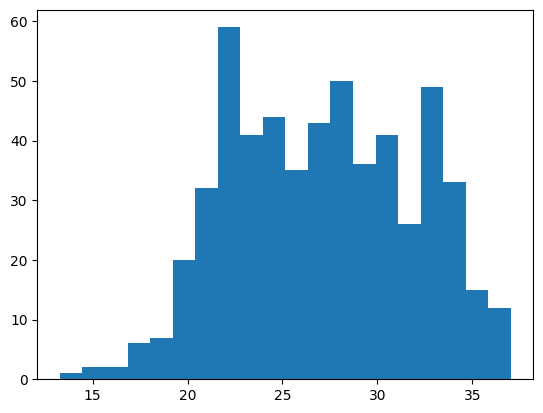

In [90]:
plt.hist(df_obs["peak_apparent_mag_g_noebv"],bins=20)

<Figure size 800x400 with 0 Axes>

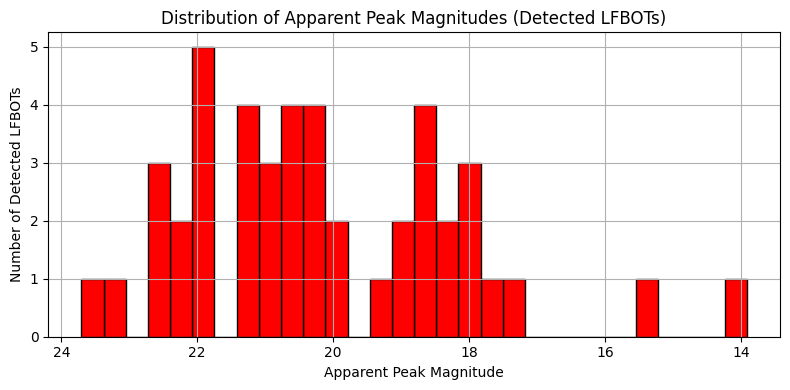

In [95]:
# Convert to numeric safely
valid_peak_mags = pd.to_numeric(detected_df['peak_mag_observed'], errors='coerce')

# Remove NaNs and cap at 99
valid_peak_mags = valid_peak_mags[np.isfinite(valid_peak_mags) & (valid_peak_mags < 99)]

# Plot
plt.figure(figsize=(8, 4))
plt.hist(valid_peak_mags, bins=30, edgecolor='black', color='red')
plt.xlabel("Apparent Peak Magnitude")
plt.ylabel("Number of Detected LFBOTs")
plt.title("Distribution of Apparent Peak Magnitudes (Detected LFBOTs)")
plt.gca().invert_xaxis()
plt.grid(True)
plt.tight_layout()
plt.show()


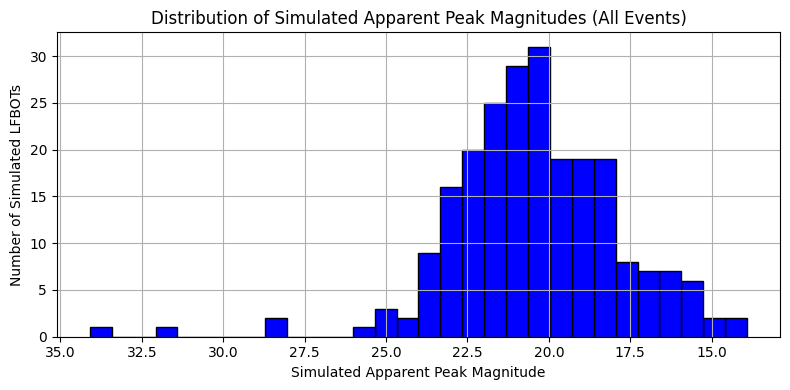

In [113]:
# All simulated events, regardless of detection
all_peak_mags = pd.to_numeric(df_obs['peak_mag_observed'], errors='coerce')
all_peak_mags = all_peak_mags[np.isfinite(all_peak_mags) & (all_peak_mags < 99)]

# Plot
plt.figure(figsize=(8, 4))
plt.hist(all_peak_mags, bins=30, edgecolor='black', color='blue')
plt.xlabel("Simulated Apparent Peak Magnitude")
plt.ylabel("Number of Simulated LFBOTs")
plt.title("Distribution of Simulated Apparent Peak Magnitudes (All Events)")
plt.gca().invert_xaxis()
plt.grid(True)
plt.tight_layout()
plt.show()


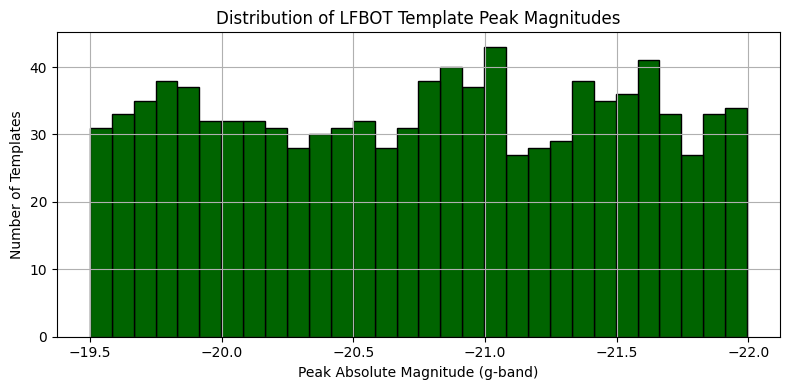

In [117]:
# Assume lc_model is your instance of LC or loaded via shared_utils
g_peak_mags = []

for lc in shared_lc_model.data:
    g_band_mag = lc['g']['mag']
    peak_mag = np.min(g_band_mag)
    g_peak_mags.append(peak_mag)

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(g_peak_mags, bins=30, edgecolor='black', color='darkgreen')
plt.xlabel("Peak Absolute Magnitude (g-band)")
plt.ylabel("Number of Templates")
plt.title("Distribution of LFBOT Template Peak Magnitudes")
plt.gca().invert_xaxis()  # brighter to the left
plt.grid(True)
plt.tight_layout()
plt.show()
